In [1]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import os
import nibabel as nib
import numpy as np

In [2]:
ROOT_DIR = "/home/theotime/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

# 2D DDPM

In [3]:
with open(f'{ROOT_DIR}/AnoDiffExperiments/analysis_per_patient/scores_patients_2d_ddpm_adc_large.json', 'r') as f:
    scores_data_adc_large = json.load(f)

with open(f'{ROOT_DIR}/AnoDiffExperiments/analysis_per_patient/scores_patients_2d_ddpm_flair_large.json', 'r') as f:
    scores_data_flair_large = json.load(f)

with open(f'{ROOT_DIR}/AnoDiffExperiments/analysis_per_patient/scores_patients_2d_ddpm_combined_large.json', 'r') as f:
    scores_data_combined_large = json.load(f)

with open(f'{ROOT_DIR}/AnoDiffExperiments/analysis_per_patient/scores_patients_2d_ddpm_adc_medium.json', 'r') as f:
    scores_data_adc_medium = json.load(f)

with open(f'{ROOT_DIR}/AnoDiffExperiments/analysis_per_patient/scores_patients_2d_ddpm_flair_medium.json', 'r') as f:
    scores_data_flair_medium = json.load(f)

with open(f'{ROOT_DIR}/AnoDiffExperiments/analysis_per_patient/scores_patients_2d_ddpm_combined_medium.json', 'r') as f:
    scores_data_combined_medium = json.load(f)

In [4]:
adc_large_dices_1x_no_post_proc = [scores_data_adc_large[patient]['1x_no_post_proc']["dice"] for patient in scores_data_adc_large]
adc_large_dices_1x_with_post_proc = [scores_data_adc_large[patient]['1x_with_post_proc']["dice"] for patient in scores_data_adc_large]


flair_large_dices_1x_no_post_proc = [scores_data_flair_large[patient]['1x_no_post_proc']["dice"] for patient in scores_data_flair_large]
flair_large_dices_1x_with_post_proc = [scores_data_flair_large[patient]['1x_with_post_proc']["dice"] for patient in scores_data_flair_large]


adc_medium_dices_1x_no_post_proc = [scores_data_adc_medium[patient]['1x_no_post_proc']["dice"] for patient in scores_data_adc_medium]
adc_medium_dices_1x_with_post_proc = [scores_data_adc_medium[patient]['1x_with_post_proc']["dice"] for patient in scores_data_adc_medium]



flair_medium_dices_1x_no_post_proc = [scores_data_flair_medium[patient]['1x_no_post_proc']["dice"] for patient in scores_data_flair_medium]
flair_medium_dices_1x_with_post_proc = [scores_data_flair_medium[patient]['1x_with_post_proc']["dice"] for patient in scores_data_flair_medium]


### Scores visualisation

In [5]:
len(adc_large_dices_1x_no_post_proc)

67

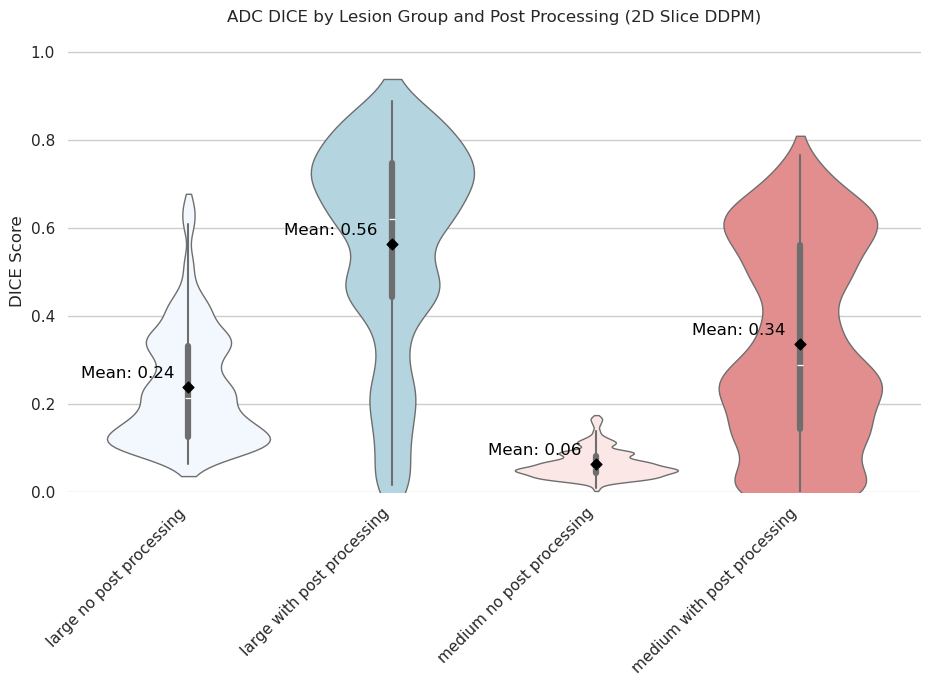

In [6]:
sns.set_theme(style="whitegrid")

# Format the data for Seaborn
plot_data = {
    "large no post processing": [v[0] for v in adc_large_dices_1x_no_post_proc if len(v) > 0],
    "large with post processing": [v[0] for v in adc_large_dices_1x_with_post_proc if len(v) > 0],
    "medium no post processing": [v[0] for v in adc_medium_dices_1x_no_post_proc if len(v) > 0],
    "medium with post processing": [v[0] for v in adc_medium_dices_1x_with_post_proc if len(v) > 0],
}

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 6))

# Define the colors for each violin
colors = ["aliceblue", "lightblue", "mistyrose", "lightcoral"]

# Draw a violinplot with a narrower bandwidth than the default
sns.violinplot(data=plot_data, bw_adjust=.5, cut=1, linewidth=1, palette=colors, ax=ax)

# Calculate and plot the mean text labels
for i, (key, vals) in enumerate(plot_data.items()):
    mean_val = sum(vals) / len(vals)
    ax.scatter(i, mean_val, color='black', s=30, zorder=3, marker='D')
    ax.text(i-0.3, mean_val + 0.02, f"Mean: {mean_val:.2f}", 
            horizontalalignment='center', size='medium', color='black')

# Rotate x labels by 45 degrees
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Finalize the figure (Dice scores range from 0 to 1)
ax.set(ylim=(0, 1.05), ylabel="DICE Score")
plt.title("ADC DICE by Lesion Group and Post Processing (2D Slice DDPM)")
sns.despine(left=True, bottom=True)


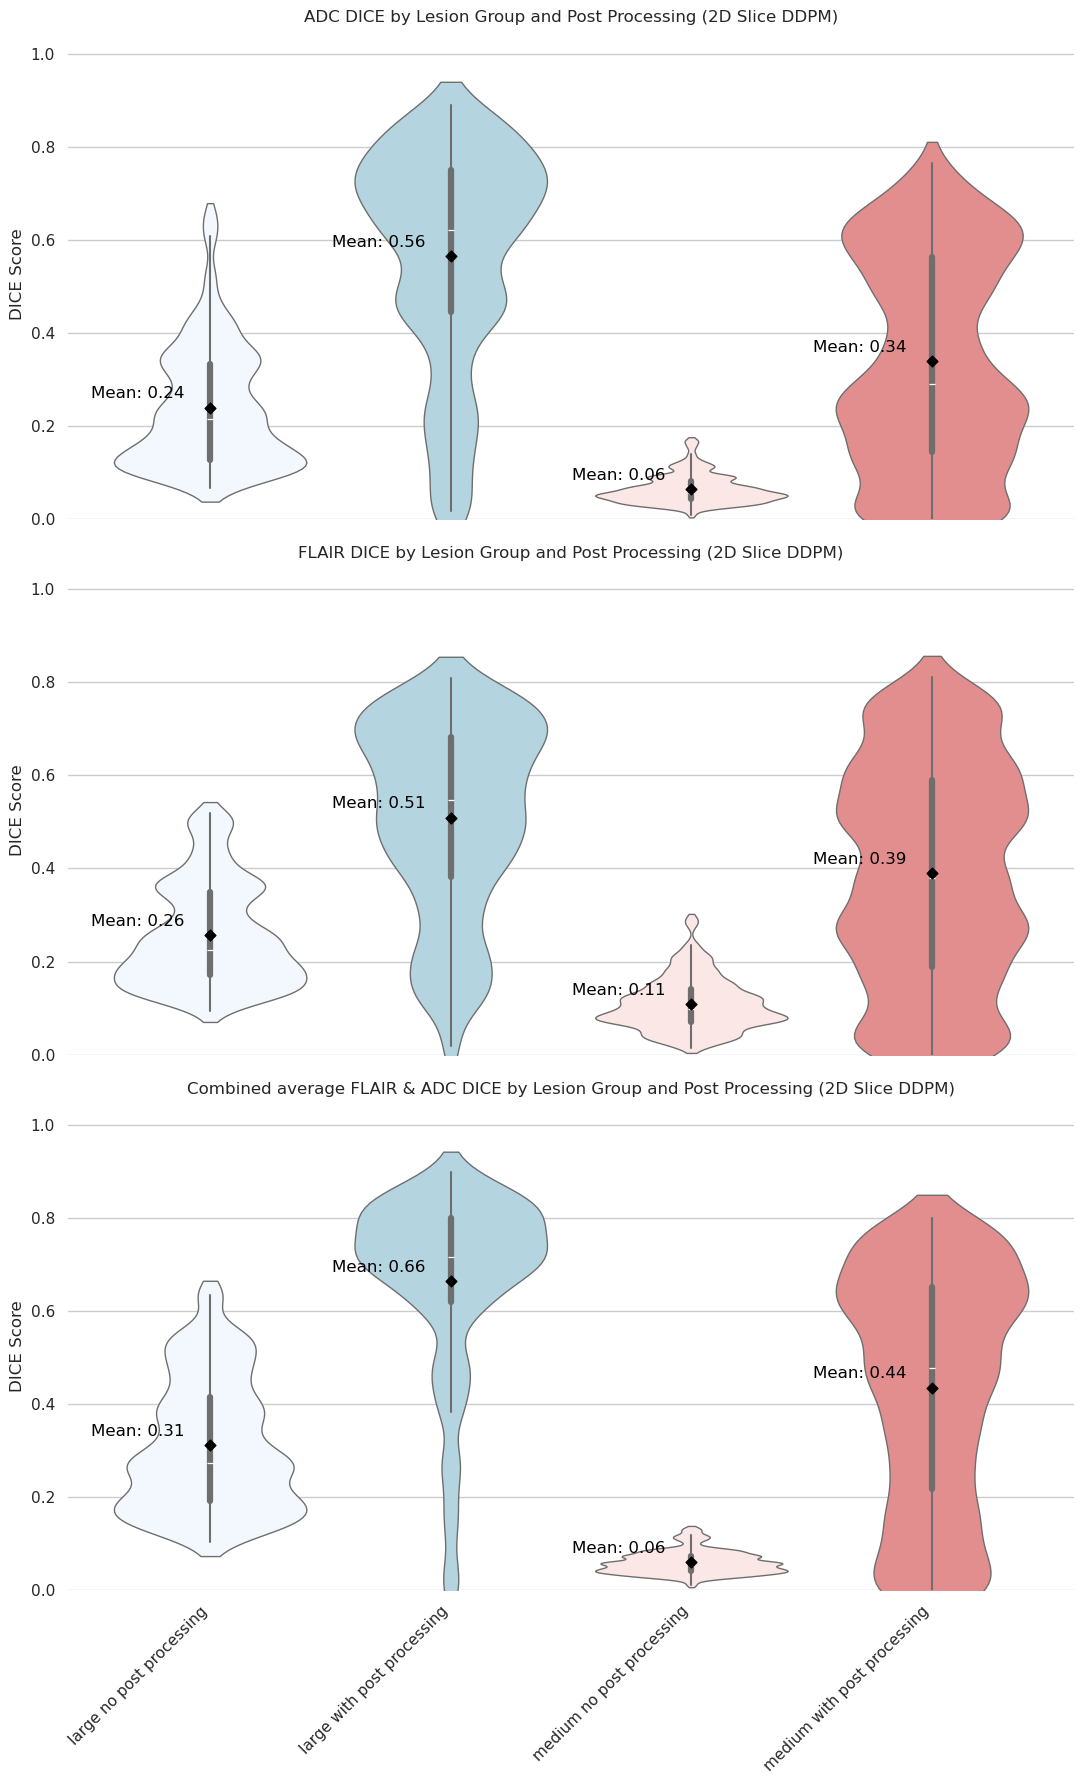

In [9]:
sns.set_theme(style="whitegrid")

def build_plot_data(large_no, large_with, medium_no, medium_with):
    return {
        "large no post processing": [v[0] for v in large_no if len(v) > 0],
        "large with post processing": [v[0] for v in large_with if len(v) > 0],
        "medium no post processing": [v[0] for v in medium_no if len(v) > 0],
        "medium with post processing": [v[0] for v in medium_with if len(v) > 0],
    }

plot_data_adc = build_plot_data(
    adc_large_dices_1x_no_post_proc,
    adc_large_dices_1x_with_post_proc,
    adc_medium_dices_1x_no_post_proc,
    adc_medium_dices_1x_with_post_proc,
)

plot_data_flair = build_plot_data(
    flair_large_dices_1x_no_post_proc,
    flair_large_dices_1x_with_post_proc,
    flair_medium_dices_1x_no_post_proc,
    flair_medium_dices_1x_with_post_proc,
)

combined_large_dices_1x_no_post_proc = [
    scores_data_combined_large[patient]["1x_no_post_proc"]["dice"]
    for patient in scores_data_combined_large
]
combined_large_dices_1x_with_post_proc = [
    scores_data_combined_large[patient]["1x_with_post_proc"]["dice"]
    for patient in scores_data_combined_large
]
combined_medium_dices_1x_no_post_proc = [
    scores_data_combined_medium[patient]["1x_no_post_proc"]["dice"]
    for patient in scores_data_combined_medium
]
combined_medium_dices_1x_with_post_proc = [
    scores_data_combined_medium[patient]["1x_with_post_proc"]["dice"]
    for patient in scores_data_combined_medium
]

plot_data_combined = build_plot_data(
    combined_large_dices_1x_no_post_proc,
    combined_large_dices_1x_with_post_proc,
    combined_medium_dices_1x_no_post_proc,
    combined_medium_dices_1x_with_post_proc,
)

fig, axes = plt.subplots(3, 1, figsize=(11, 18), sharey=True)
colors = ["aliceblue", "lightblue", "mistyrose", "lightcoral"]

def plot_violin(ax, data, title, show_xticklabels=False):
    sns.violinplot(data=data, bw_adjust=.5, cut=1, linewidth=1, palette=colors, ax=ax)
    for i, vals in enumerate(data.values()):
        if not vals:
            continue
        mean_val = sum(vals) / len(vals)
        ax.scatter(i, mean_val, color='black', s=30, zorder=3, marker='D')
        ax.text(i - 0.3, mean_val + 0.02, f"Mean: {mean_val:.2f}",
                horizontalalignment='center', size='medium', color='black')
    if show_xticklabels:
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    else:
        ax.tick_params(axis='x', labelbottom=False)
    ax.set(ylim=(0, 1.05), ylabel="DICE Score")
    ax.set_title(title)
    sns.despine(ax=ax, left=True, bottom=True)

plot_violin(axes[0], plot_data_adc, "ADC DICE by Lesion Group and Post Processing (2D Slice DDPM)", show_xticklabels=False)
plot_violin(axes[1], plot_data_flair, "FLAIR DICE by Lesion Group and Post Processing (2D Slice DDPM)", show_xticklabels=False)
plot_violin(axes[2], plot_data_combined, "Combined average FLAIR & ADC DICE by Lesion Group and Post Processing (2D Slice DDPM)", show_xticklabels=True)

plt.tight_layout()


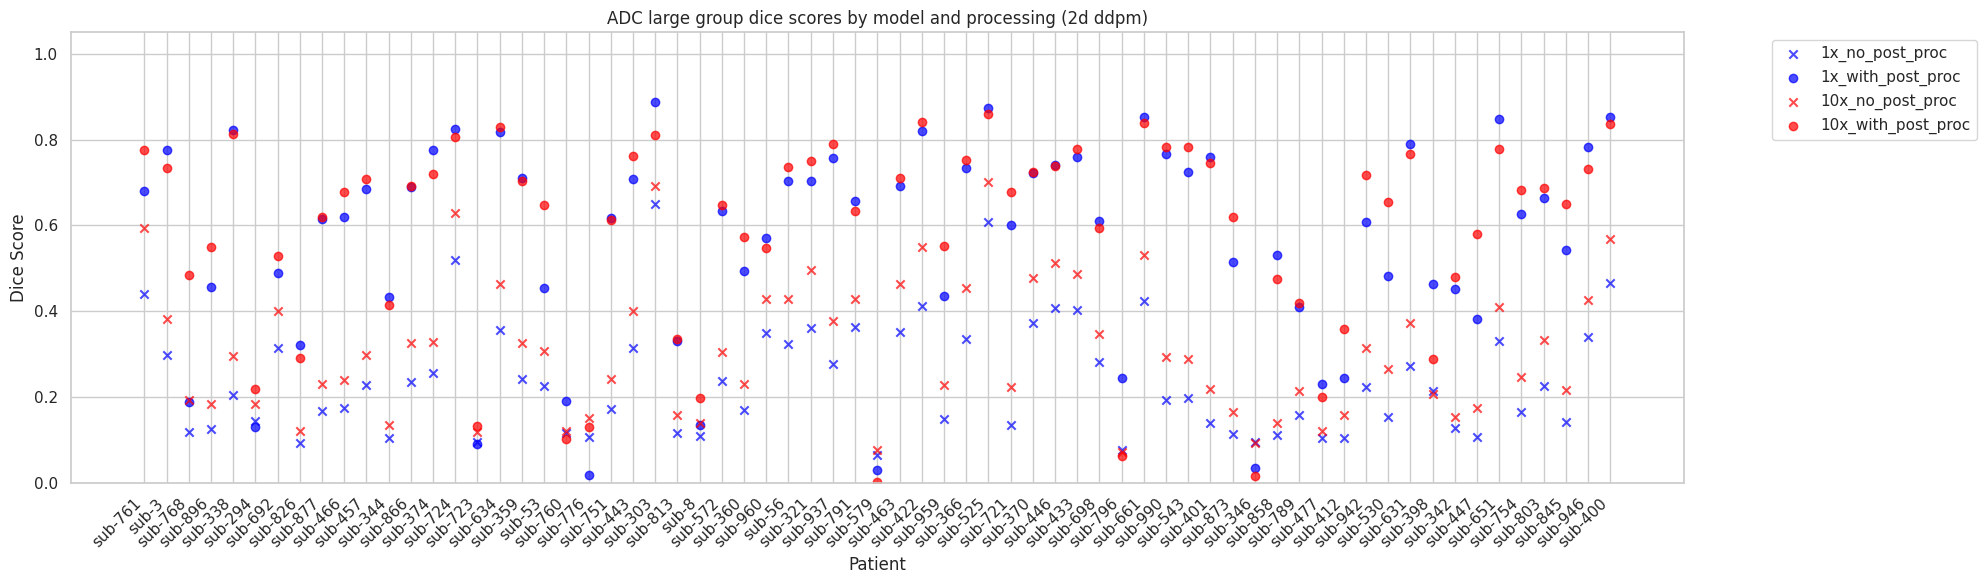

In [6]:
plt.figure(figsize=(20, 6))

markers = ['x', 'o', 'x', 'o']
colors = ['blue', 'blue', 'red', 'red']
patient_names = list(scores_data.keys())

for (key, vals), marker, color in zip(plot_data.items(), markers, colors):
    plt.scatter(range(len(vals)), vals, label=key, marker=marker, alpha=0.7, c=color)

plt.xticks(range(len(patient_names)), patient_names, rotation=45, ha='right')
plt.xlabel("Patient")
plt.ylabel("Dice Score")
plt.title("ADC large group dice scores by model and processing (2d ddpm)")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

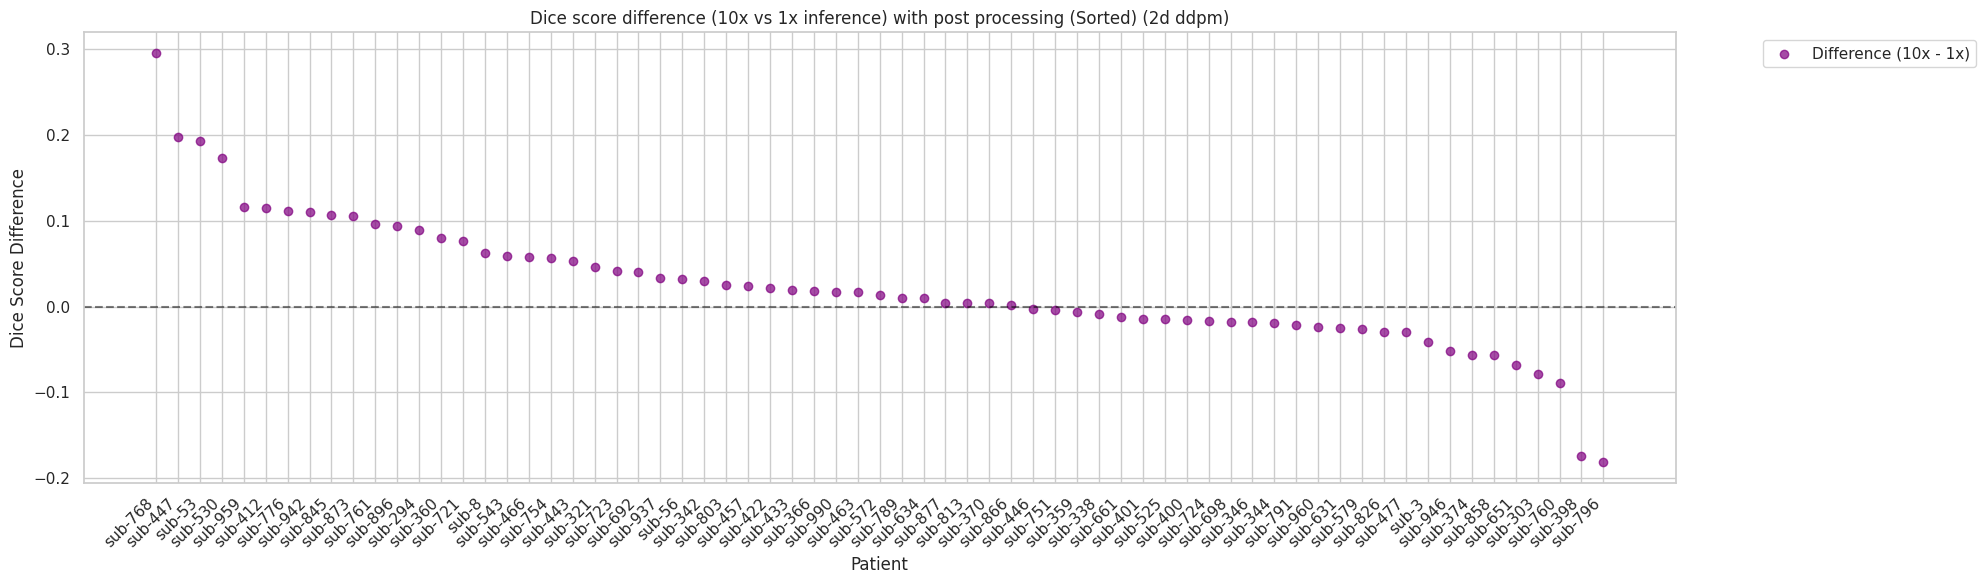

In [7]:
plt.figure(figsize=(20, 6))

patient_names = list(scores_data.keys())

# Calculate the difference between 10x and 1x with post processing
diffs = [
    val_10x - val_1x 
    for val_10x, val_1x in zip(plot_data["10x_with_post_proc"], plot_data["1x_with_post_proc"])
]

# Sort the differences and keep the patient names aligned
sorted_pairs = sorted(zip(diffs, patient_names), reverse=True)
sorted_diffs, sorted_patient_names = zip(*sorted_pairs)

plt.scatter(range(len(sorted_diffs)), sorted_diffs, label='Difference (10x - 1x)', marker='o', alpha=0.7, c='purple')

# Add a horizontal line at 0 for reference
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.xticks(range(len(sorted_patient_names)), sorted_patient_names, rotation=45, ha='right')
plt.xlabel("Patient")
plt.ylabel("Dice Score Difference")
plt.title("Dice score difference (10x vs 1x inference) with post processing (Sorted) (2d ddpm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Images visualisation

In [10]:
adc_folder = ROOT_DIR+"/datasets/final_soop_dataset_small/adc_registered"

ano_maps_1x_inference_adc_large = ROOT_DIR+"datasets/anomaly_maps/exp_2_2_fixed/large"
ano_maps_10x_inference_adc_large = ROOT_DIR+"datasets/anomaly_maps/exp_2_2_10x_inference/large"

ano_segmentation_no_post_proc_1x_inference_adc_large = ROOT_DIR+"datasets/segmentations/exp_2_2_fixed/segmentation_1x_no_post_proc"
ano_segmentation_no_post_proc_10x_inference_adc_large = ROOT_DIR+"datasets/segmentations/exp_2_2_10x_inference/segmentation_10x_no_post_proc"

ano_segmentation_with_post_proc_1x_inference_adc_large = ROOT_DIR+"datasets/segmentations/exp_2_2_fixed/segmentation_1x_with_post_proc"
ano_segmentation_with_post_proc_10x_inference_adc_large = ROOT_DIR+"datasets/segmentations/exp_2_2_10x_inference/segmentation_10x_with_post_proc"

ground_truth_masks = ROOT_DIR+"datasets/final_soop_dataset_small/masks_combined_registered"

In [11]:
patients_to_visualize = ["sub-651", "sub-303", "sub-760", "sub-398", "sub-796"]
#patients_to_visualize = ["sub-579", "sub-760", "sub-776", "sub-723", "sub-796", "sub-346"]

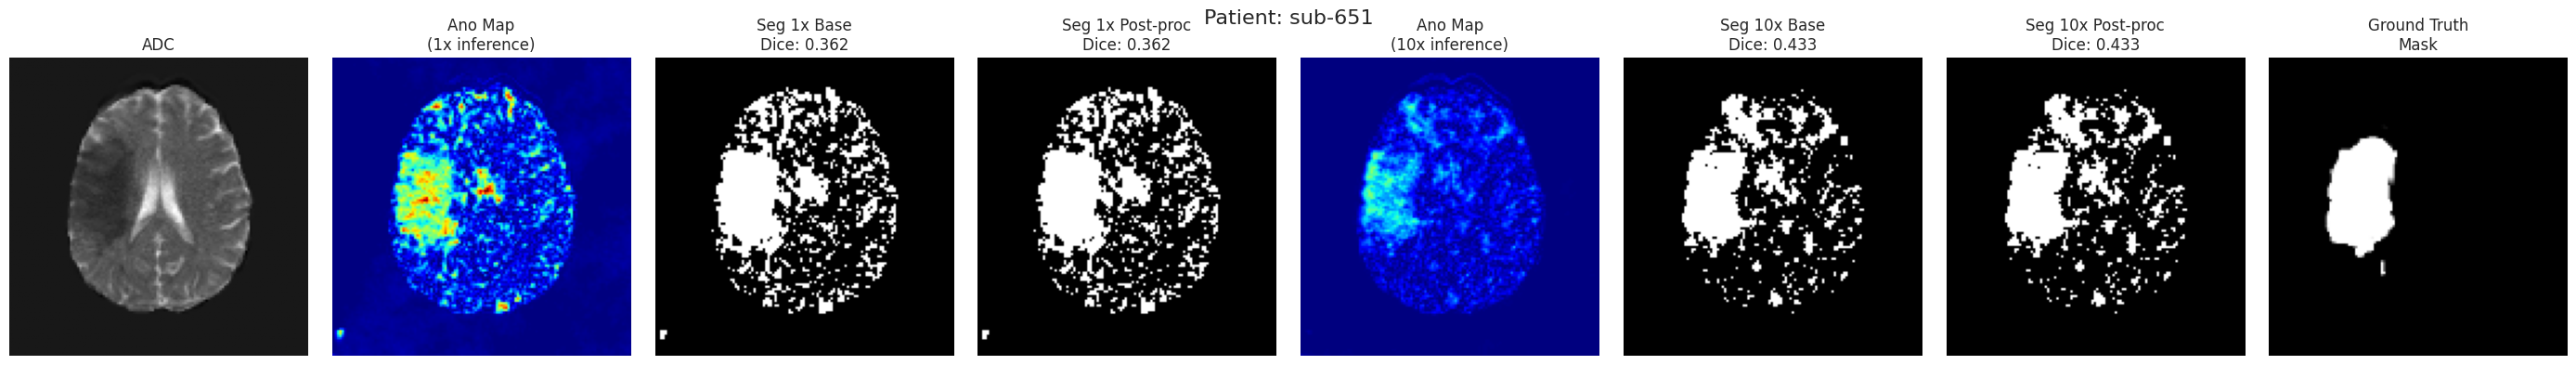

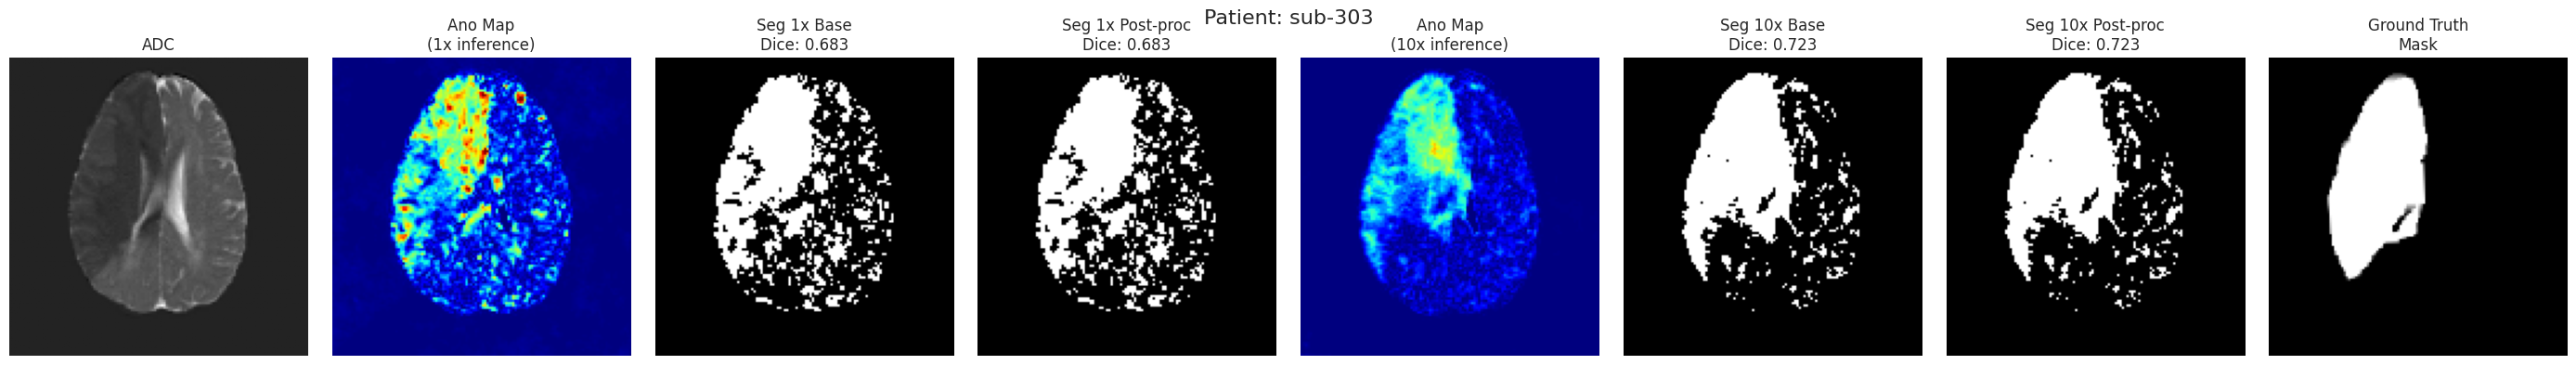

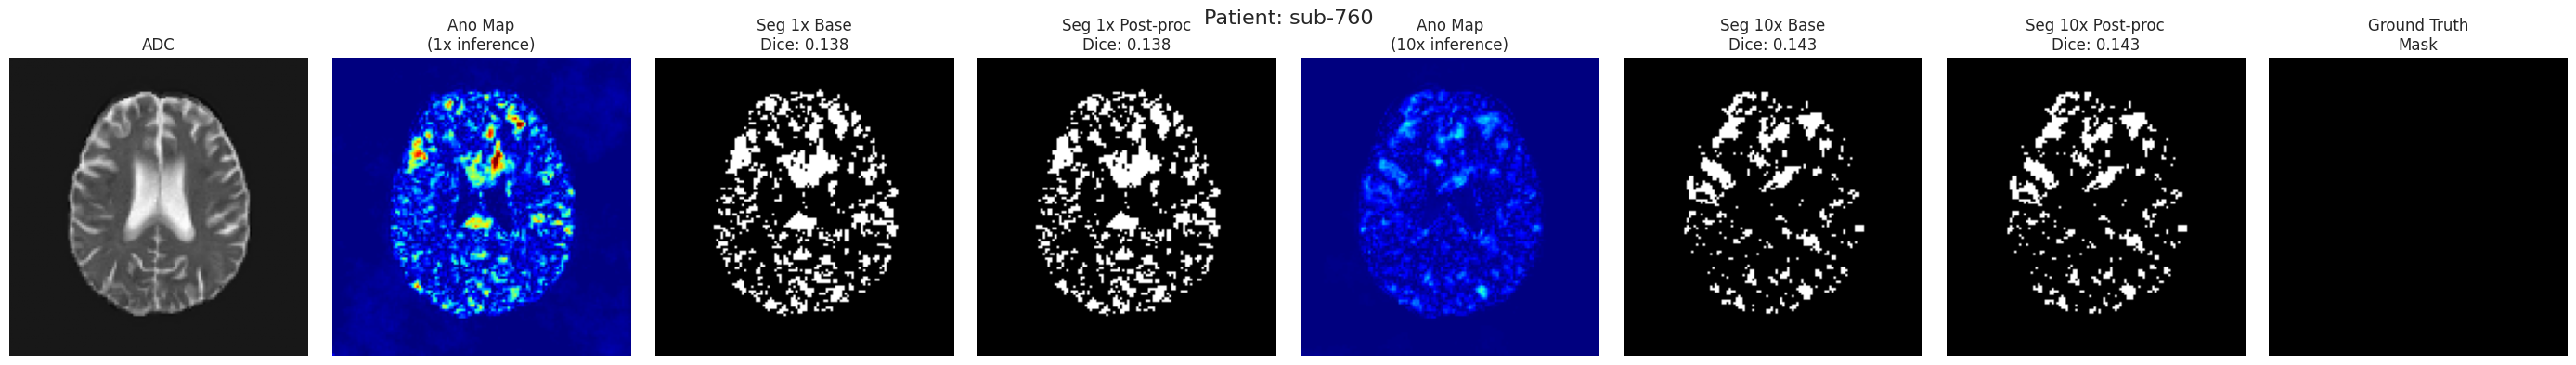

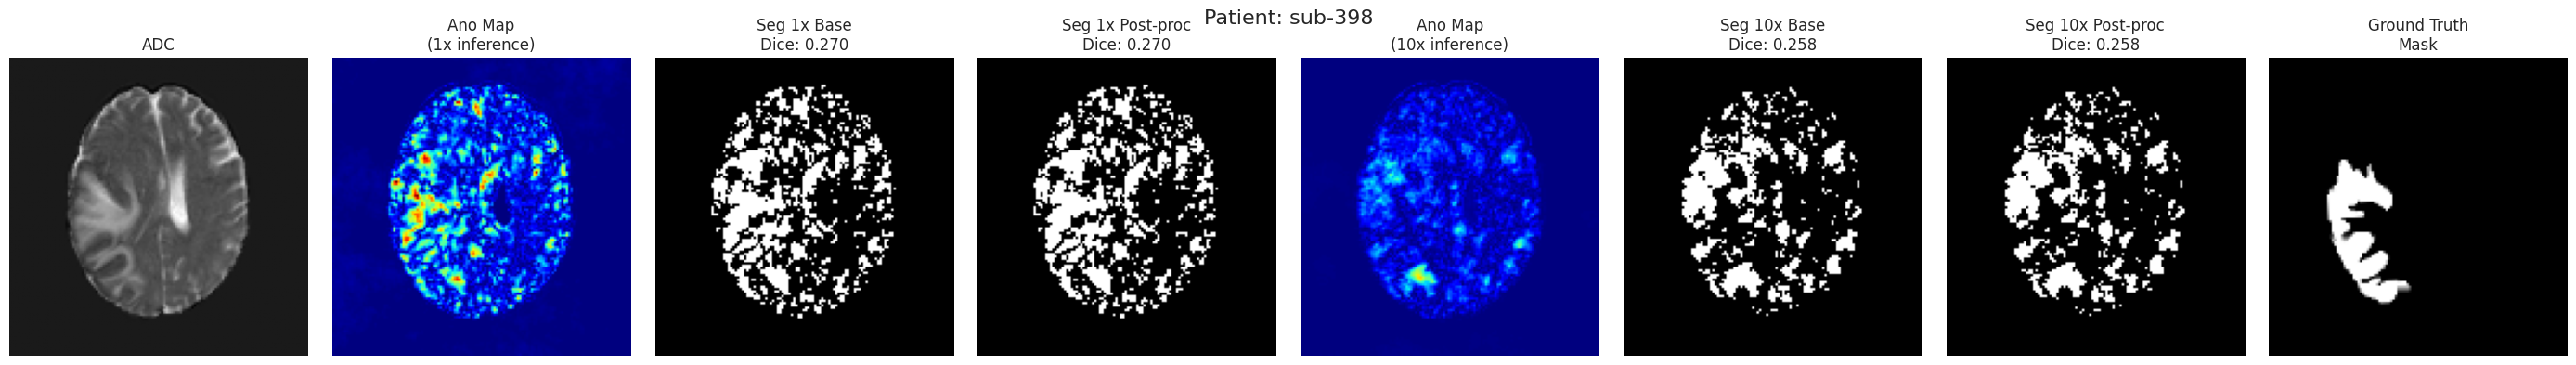

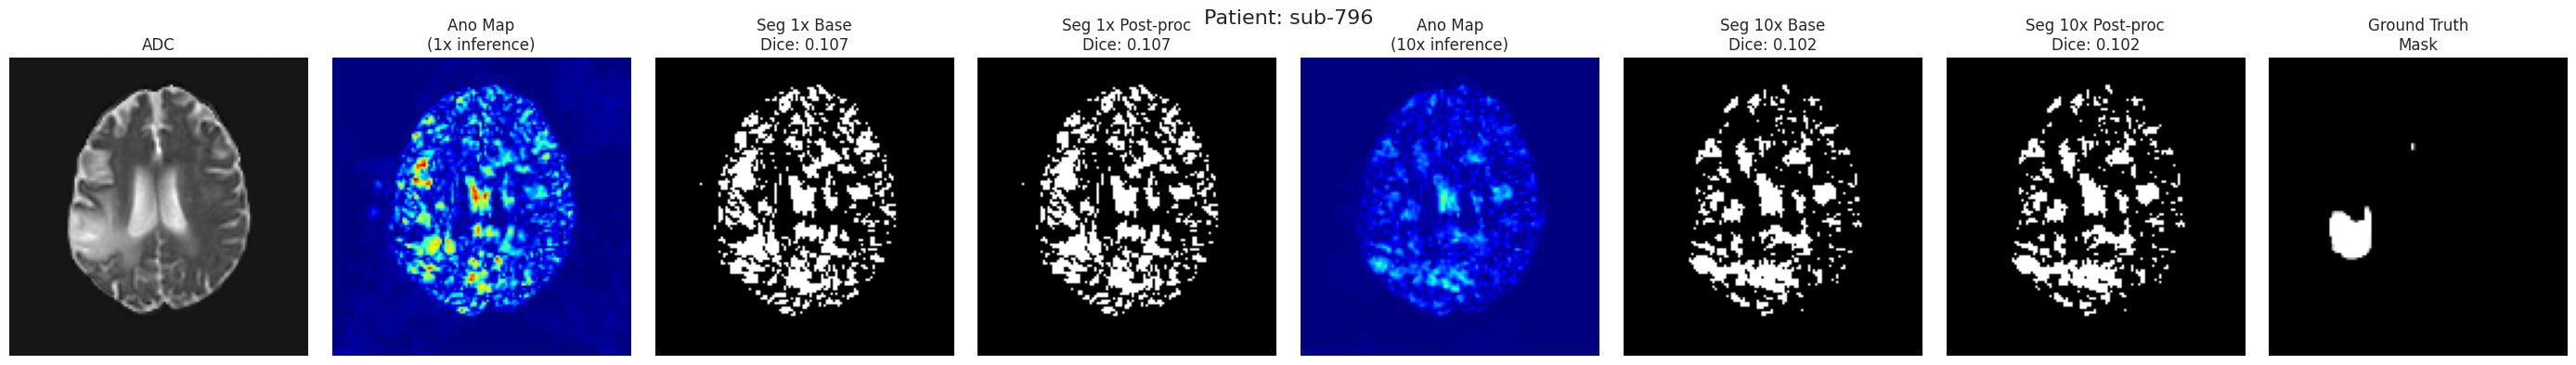

In [12]:


def compute_dice(pred, target):
    intersection = np.logical_and(pred, target)
    if pred.sum() + target.sum() == 0:
        return 1.0
    return 2. * intersection.sum() / (pred.sum() + target.sum())

def get_middle_slice(volume):
    # Assuming standard medical image orientation where the 3rd axis is axial
    z = volume.shape[2] // 2
    return np.rot90(volume[:, :, z])

for patient in patients_to_visualize:
    try:
        # Load volumes
        adc = nib.load(os.path.join(adc_folder, f"{patient}.nii.gz")).get_fdata()
        gt = nib.load(os.path.join(ground_truth_masks, f"{patient}.nii.gz")).get_fdata()
        
        map_1x = nib.load(os.path.join(ano_maps_1x_inference_adc_large, f"{patient}.nii.gz")).get_fdata()
        map_10x = nib.load(os.path.join(ano_maps_10x_inference_adc_large, f"{patient}.nii.gz")).get_fdata()
        
        seg_1x_no = nib.load(os.path.join(ano_segmentation_no_post_proc_1x_inference_adc_large, f"{patient}.nii.gz")).get_fdata()
        seg_10x_no = nib.load(os.path.join(ano_segmentation_no_post_proc_10x_inference_adc_large, f"{patient}.nii.gz")).get_fdata()
        
        seg_1x_post = nib.load(os.path.join(ano_segmentation_with_post_proc_1x_inference_adc_large, f"{patient}.nii.gz")).get_fdata()
        seg_10x_post = nib.load(os.path.join(ano_segmentation_with_post_proc_10x_inference_adc_large, f"{patient}.nii.gz")).get_fdata()
        
        # Compute Dice metrics based on the entire 3D volume
        dice_1x_no = compute_dice(seg_1x_no, gt)
        dice_10x_no = compute_dice(seg_10x_no, gt)
        dice_1x_post = compute_dice(seg_1x_post, gt)
        dice_10x_post = compute_dice(seg_10x_post, gt)

        # Plotting
        fig, axes = plt.subplots(1, 8, figsize=(28, 4))
        plt.suptitle(f"Patient: {patient}", fontsize=16)
        
        axes[0].imshow(get_middle_slice(adc), cmap='gray')
        axes[0].set_title("ADC")
        

        axes[1].imshow(get_middle_slice(map_1x), cmap='jet', vmin=0, vmax=0.3)
        axes[1].set_title("Ano Map\n(1x inference)")

        axes[2].imshow(get_middle_slice(seg_1x_no), cmap='gray')
        axes[2].set_title(f"Seg 1x Base\nDice: {dice_1x_no:.3f}")

        axes[3].imshow(get_middle_slice(seg_1x_post), cmap='gray')
        axes[3].set_title(f"Seg 1x Post-proc\nDice: {dice_1x_post:.3f}")

        
        axes[4].imshow(get_middle_slice(map_10x), cmap='jet', vmin=0, vmax=0.3)
        axes[4].set_title("Ano Map\n(10x inference)")
        
        axes[5].imshow(get_middle_slice(seg_10x_no), cmap='gray')
        axes[5].set_title(f"Seg 10x Base\nDice: {dice_10x_no:.3f}")
        
        
        axes[6].imshow(get_middle_slice(seg_10x_post), cmap='gray')
        axes[6].set_title(f"Seg 10x Post-proc\nDice: {dice_10x_post:.3f}")


        axes[7].imshow(get_middle_slice(gt), cmap='gray')
        axes[7].set_title("Ground Truth\nMask")
        
        for ax in axes:
            ax.axis('off')
            
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError as e:
        print(f"Could not load data for {patient}: {e}")

# FLAIR 2D DDPM

In [8]:
with open(f'{ROOT_DIR}/AnoDiffExperiments/analysis_nb_inferences_per_patient/scores_patients_2d_ddpm_flair_verify.json', 'r') as f:
    scores_data = json.load(f)

In [9]:
dices_1x_no_post_proc = [scores_data[patient]['1x_no_post_proc']["dice"] for patient in scores_data]
dices_1x_with_post_proc = [scores_data[patient]['1x_with_post_proc']["dice"] for patient in scores_data]

dices_10x_no_post_proc = [scores_data[patient]['10x_no_post_proc']["dice"] for patient in scores_data]
dices_10x_with_post_proc = [scores_data[patient]['10x_with_post_proc']["dice"] for patient in scores_data]

### Scores visualisation

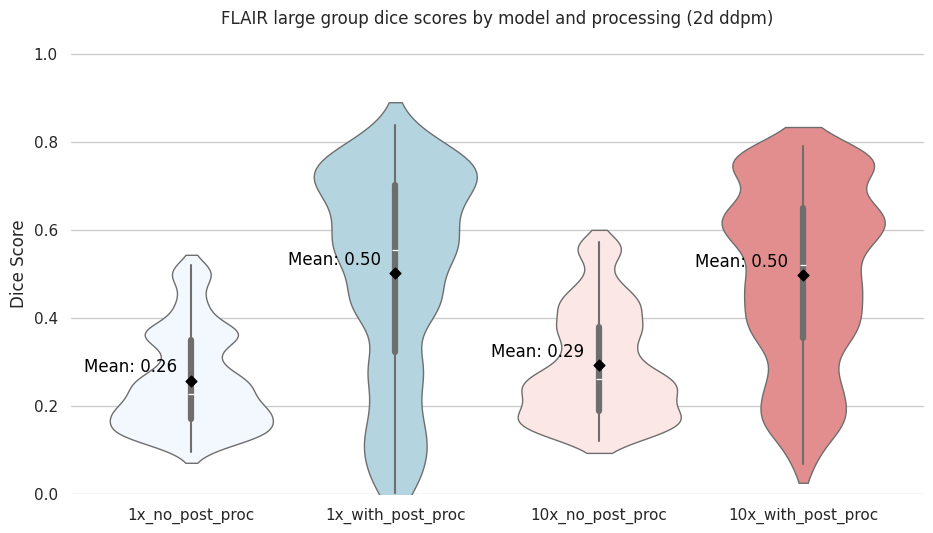

In [10]:
sns.set_theme(style="whitegrid")

# Format the data for Seaborn
plot_data = {
    "1x_no_post_proc": [v[0] for v in dices_1x_no_post_proc],
    "1x_with_post_proc": [v[0] for v in dices_1x_with_post_proc],
    "10x_no_post_proc": [v[0] for v in dices_10x_no_post_proc],
    "10x_with_post_proc": [v[0] for v in dices_10x_with_post_proc]
}

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 6))

# Define the colors for each violin
colors = ["aliceblue", "lightblue", "mistyrose", "lightcoral"]

# Draw a violinplot with a narrower bandwidth than the default
sns.violinplot(data=plot_data, bw_adjust=.5, cut=1, linewidth=1, palette=colors, ax=ax)

# Calculate and plot the mean text labels
for i, (key, vals) in enumerate(plot_data.items()):
    mean_val = sum(vals) / len(vals)
    ax.scatter(i, mean_val, color='black', s=30, zorder=3, marker='D')
    ax.text(i-0.3, mean_val + 0.02, f"Mean: {mean_val:.2f}", 
            horizontalalignment='center', size='medium', color='black')

# Finalize the figure (Dice scores range from 0 to 1)
ax.set(ylim=(0, 1.05), ylabel="Dice Score")
plt.title("FLAIR large group dice scores by model and processing (2d ddpm)")
sns.despine(left=True, bottom=True)


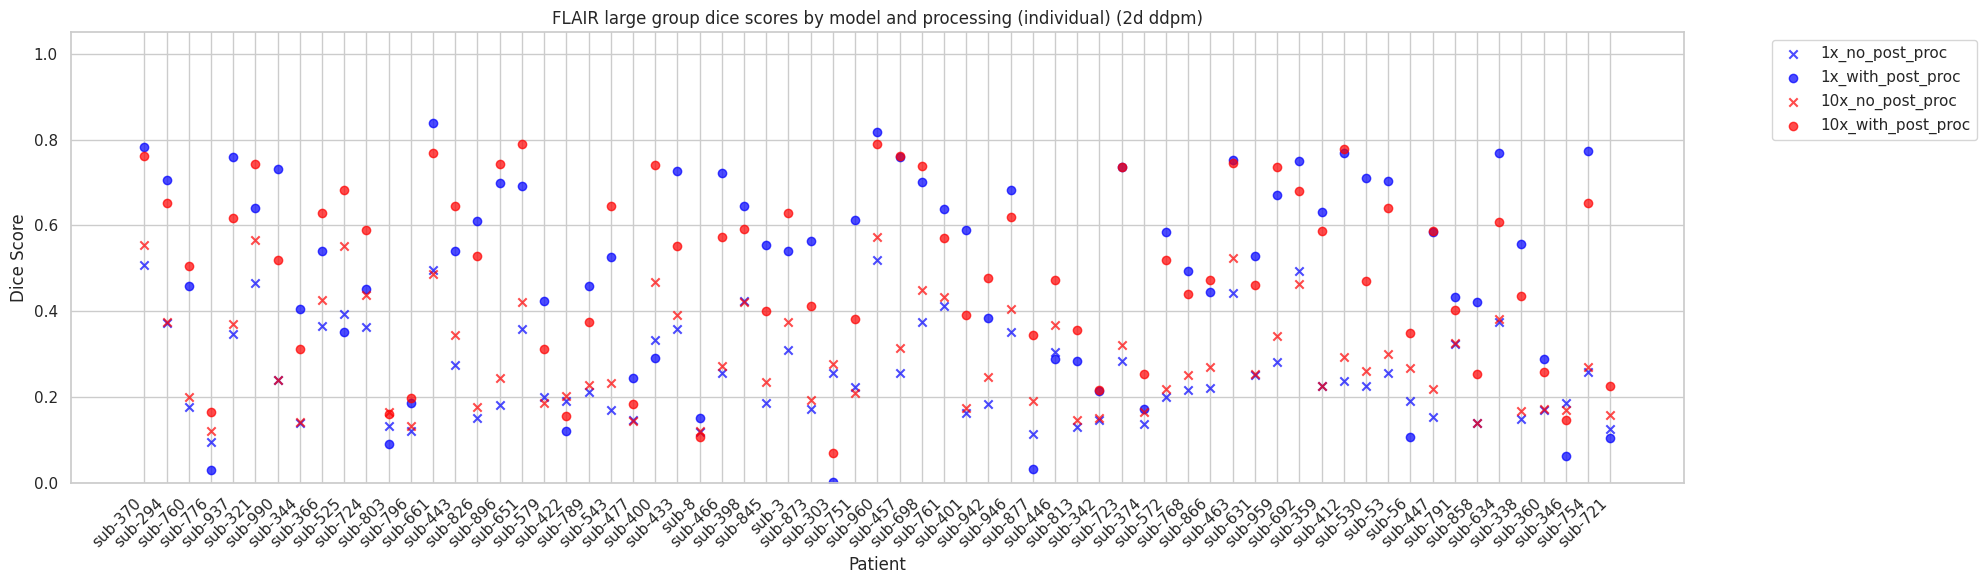

In [13]:
plt.figure(figsize=(20, 6))

markers = ['x', 'o', 'x', 'o']
colors = ['blue', 'blue', 'red', 'red']
patient_names = list(scores_data.keys())

for (key, vals), marker, color in zip(plot_data.items(), markers, colors):
    plt.scatter(range(len(vals)), vals, label=key, marker=marker, alpha=0.7, c=color)

plt.xticks(range(len(patient_names)), patient_names, rotation=45, ha='right')
plt.xlabel("Patient")
plt.ylabel("Dice Score")
plt.title("FLAIR large group dice scores by model and processing (individual) (2d ddpm)")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

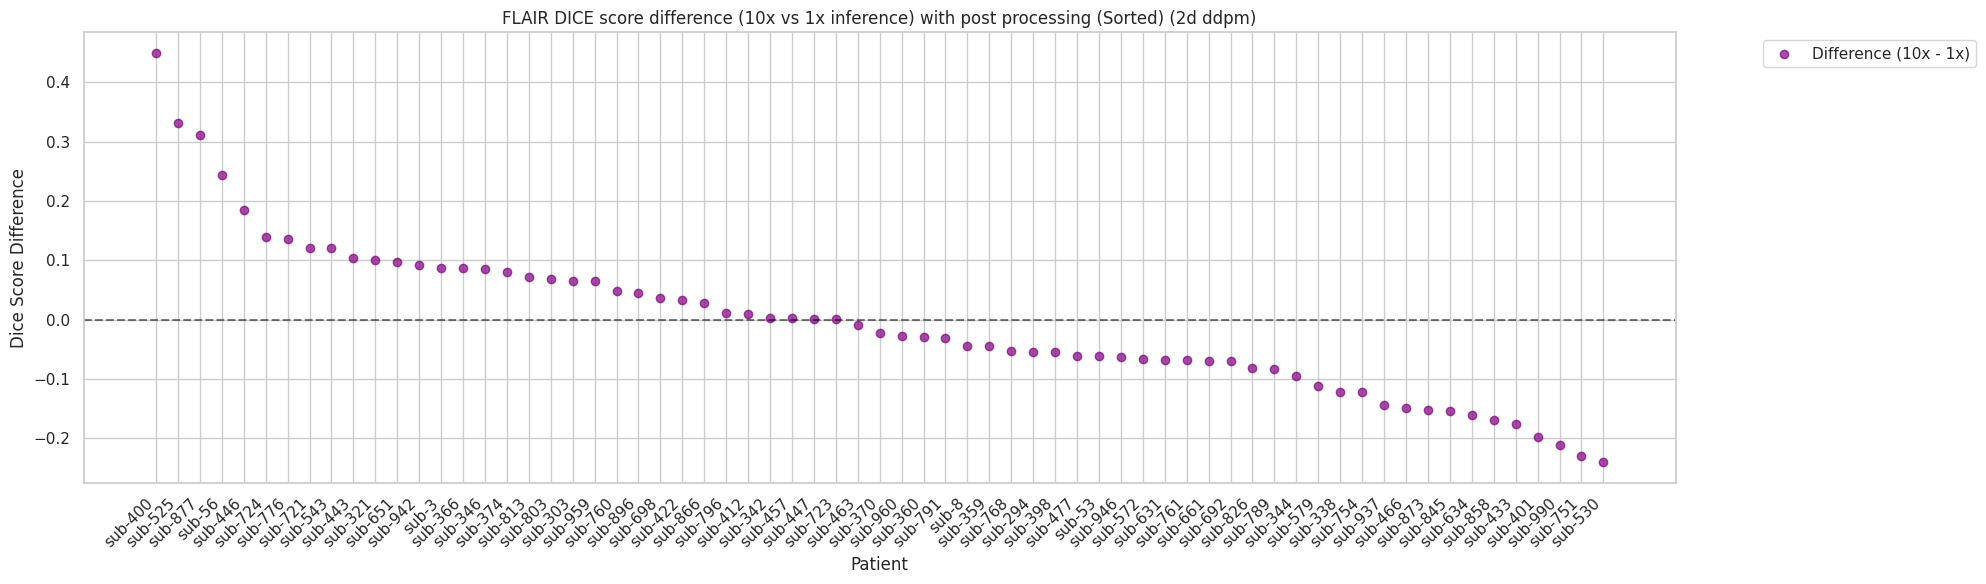

In [14]:
plt.figure(figsize=(20, 6))

patient_names = list(scores_data.keys())

# Calculate the difference between 10x and 1x with post processing
diffs = [
    val_10x - val_1x 
    for val_10x, val_1x in zip(plot_data["10x_with_post_proc"], plot_data["1x_with_post_proc"])
]

# Sort the differences and keep the patient names aligned
sorted_pairs = sorted(zip(diffs, patient_names), reverse=True)
sorted_diffs, sorted_patient_names = zip(*sorted_pairs)

plt.scatter(range(len(sorted_diffs)), sorted_diffs, label='Difference (10x - 1x)', marker='o', alpha=0.7, c='purple')

# Add a horizontal line at 0 for reference
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.xticks(range(len(sorted_patient_names)), sorted_patient_names, rotation=45, ha='right')
plt.xlabel("Patient")
plt.ylabel("Dice Score Difference")
plt.title("FLAIR DICE score difference (10x vs 1x inference) with post processing (Sorted) (2d ddpm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()